In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score, balanced_accuracy_score

print("TensorFlow:", tf.__version__)

2026-05-05 13:02:13.116932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777986133.300808      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777986133.350533      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777986133.781324      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777986133.781369      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777986133.781372      57 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


In [2]:
DATASET_DIR = Path("/kaggle/input/datasets/malakdiab04/hieroglyph-classification-augmented-trial-2")

TRAIN_DIR = DATASET_DIR / "train/train"
VAL_DIR = DATASET_DIR / "val/val"
TEST_DIR = DATASET_DIR / "test/test"

IMG_SIZE = 256
BATCH_SIZE = 32
SEED = 42

EPOCHS_HEAD = 25
EPOCHS_FINE_1 = 10

LR_HEAD = 2e-4
LR_FINE_1 = 5e-7

WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
val_classes = sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()])
test_classes = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Train classes:", len(train_classes))
print("Val classes:", len(val_classes))
print("Test classes:", len(test_classes))

print("Example classes:", train_classes[:20])

Train exists: True
Val exists: True
Test exists: True
Train classes: 718
Val classes: 705
Test classes: 562
Example classes: ['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A2', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27']


In [4]:
def count_images_per_class(split_dir):
    rows = []
    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        count = sum(
            1 for p in class_dir.iterdir()
            if p.is_file() and p.suffix.lower() in image_exts
        )

        rows.append({
            "label": class_dir.name,
            "count": count
        })

    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

In [5]:
train_counts = count_images_per_class(TRAIN_DIR)
val_counts = count_images_per_class(VAL_DIR)
test_counts = count_images_per_class(TEST_DIR)

print("Train images:", train_counts["count"].sum())
print("Val images:", val_counts["count"].sum())
print("Test images:", test_counts["count"].sum())

display(train_counts.head(20))
display(train_counts.tail(20))

Train images: 45325
Val images: 2686
Test images: 2582


,label,count
0,O4,200
1,Y5,200
2,D21,200
3,S34,200
4,A1,200
5,X1,200
6,G17,200
7,G43,200
8,M17,200
9,V30,200


,label,count
698,S5,30
699,N13,30
700,O26,30
701,P11,30
702,S7,30
703,A33,30
704,O44,30
705,O64,15
706,G144,15
707,M163,15


In [6]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}

class_names = train_classes
NUM_CLASSES = len(class_names)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("NUM_CLASSES:", NUM_CLASSES)
print("Example mapping:", list(class_to_idx.items())[:10])

NUM_CLASSES: 718
Example mapping: [('A1', 0), ('A10', 1), ('A11', 2), ('A12', 3), ('A13', 4), ('A14', 5), ('A15', 6), ('A16', 7), ('A17', 8), ('A18', 9)]


In [7]:
def build_split_df(split_dir, class_to_idx):
    rows = []

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        label = class_dir.name

        if label not in class_to_idx:
            continue

        label_idx = class_to_idx[label]

        for img_path in class_dir.iterdir():
            if img_path.is_file() and img_path.suffix.lower() in IMAGE_EXTS:
                rows.append({
                    "filepath": str(img_path),
                    "label": label,
                    "label_idx": label_idx
                })

    return pd.DataFrame(rows)

In [8]:
train_df = build_split_df(TRAIN_DIR, class_to_idx)
val_df = build_split_df(VAL_DIR, class_to_idx)
test_df = build_split_df(TEST_DIR, class_to_idx)

print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))

print("Train classes:", train_df["label"].nunique())
print("Val classes:", val_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

display(train_df.head())

Train images: 45325
Val images: 2686
Test images: 2582
Train classes: 718
Val classes: 705
Test classes: 562


,filepath,label,label_idx
0,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
1,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
2,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
3,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614
4,/kaggle/input/datasets/malakdiab04/hieroglyph-...,U35,614


In [9]:
def decode_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label_idx"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [10]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print(train_ds)

I0000 00:00:1777986203.969016      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 718), dtype=tf.float32, name=None))>


In [12]:
images, labels = next(iter(train_ds))

label_ids = np.argmax(labels.numpy(), axis=1)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels example:", labels[:10].numpy())
print("Label IDs example:", label_ids[:10])
print("Class names example:", [class_names[i] for i in label_ids[:10]])

Images shape: (32, 256, 256, 3)
Labels shape: (32, 718)
Labels example: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Label IDs example: [543 462 631  81 694 120 375 366 286 349]
Class names example: ['S43', 'O9', 'V13', 'D1', 'X6', 'D45', 'N23', 'N15', 'H8', 'M4']


Total classes: 718
Total images: 45325


label
G43    200
Q3     200
F31    200
F35    200
M17    200
V30    200
O49    200
S29    200
O34    200
D36    200
Name: count, dtype: int64

label
P13     15
O62     15
O206    15
O307    15
O292    15
O54     15
A282    15
P36     15
F102    15
D154    15
Name: count, dtype: int64

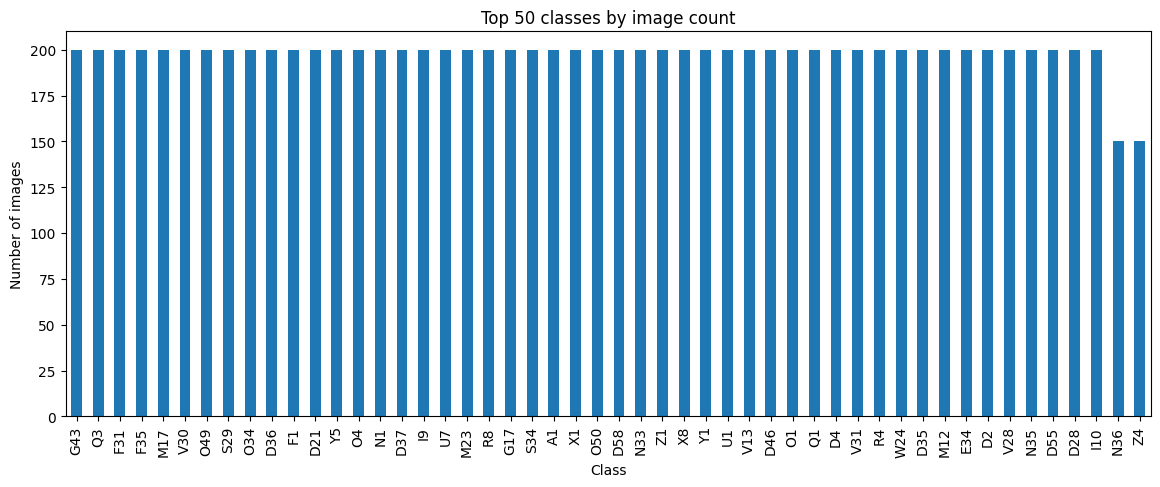

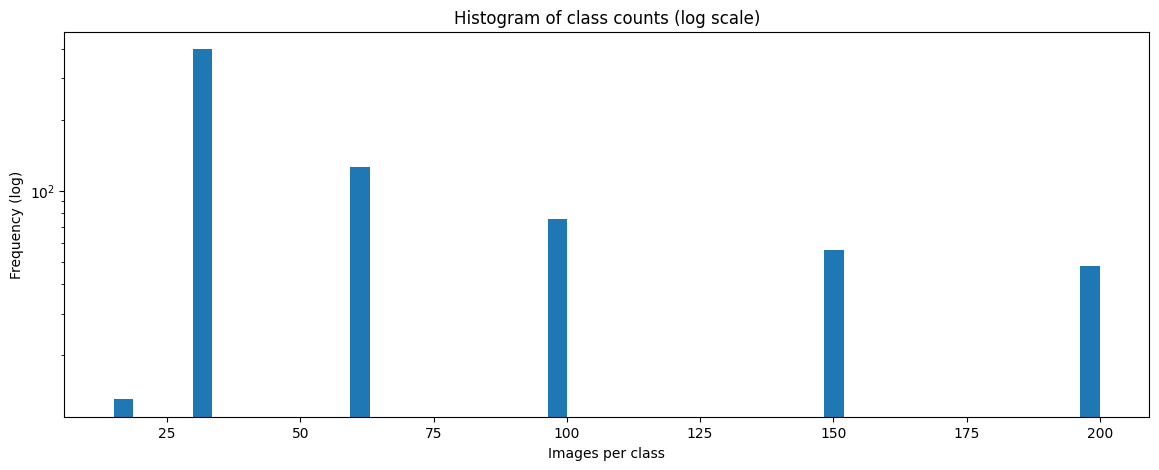

In [13]:
train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Total classes:", len(train_class_counts))
print("Total images:", train_class_counts.sum())

display(train_class_counts.head(10))
display(train_class_counts.tail(10))

plt.figure(figsize=(14,5))
train_class_counts.head(50).plot(kind="bar")
plt.title("Top 50 classes by image count")
plt.ylabel("Number of images")
plt.xlabel("Class")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,5))
train_class_counts.plot(kind="hist", bins=50)
plt.yscale("log")
plt.title("Histogram of class counts (log scale)")
plt.xlabel("Images per class")
plt.ylabel("Frequency (log)")
plt.show()

In [14]:
freq_series = train_class_counts.value_counts().sort_index()

freq = pd.DataFrame({
    "images_per_class": freq_series.index,
    "num_classes": freq_series.values
})

display(freq)

,images_per_class,num_classes
0,15,13
1,30,399
2,60,126
3,100,76
4,150,56
5,200,48


In [15]:
max_count = train_class_counts.max()
min_count = train_class_counts.min()

print("Max:", max_count)
print("Min:", min_count)
print("Ratio:", max_count / min_count)

Max: 200
Min: 15
Ratio: 13.333333333333334


In [16]:
train_label_indices = train_df["label_idx"].values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_label_indices
)

weights = np.sqrt(weights)

class_weights = {i: float(w) for i, w in enumerate(weights)}

print("Min class weight:", min(class_weights.values()))
print("Max class weight:", max(class_weights.values()))
print("Example weights:", list(class_weights.items())[:10])

Min class weight: 0.5618128734154959
Max class weight: 2.051450559109744
Example weights: [(0, 0.5618128734154959), (1, 1.450594601615434), (2, 1.450594601615434), (3, 1.450594601615434), (4, 1.450594601615434), (5, 1.025725279554872), (6, 1.025725279554872), (7, 1.450594601615434), (8, 1.025725279554872), (9, 1.450594601615434)]


In [17]:
online_aug = keras.Sequential([
    layers.RandomRotation(0.025),
    layers.RandomZoom(0.04),
    layers.RandomTranslation(0.025, 0.025),
    layers.RandomContrast(0.05),
    layers.RandomBrightness(0.05),
    layers.GaussianNoise(0.02),
], name="online_augmentation")

In [18]:
preprocess_input = tf.keras.applications.resnet_v2.preprocess_input

base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = online_aug(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dropout(0.45)(x)
x = layers.Dense(512,activation="gelu",kernel_regularizer=keras.regularizers.l2(WEIGHT_DECAY))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax",dtype="float32")(x)

model = keras.Model(inputs, outputs)
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ online_augmentation             │ (None, 256, 256, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 8, 8, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 718)            │       368,334 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,992,462 (95.34 MB)

 Trainable params: 1,422,542 (5.43 MB)

 Non-trainable params: 23,569,920 (89.91 MB)

### Head Stage

In [19]:
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_HEAD,weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3"),
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5")
    ]
)

In [20]:
callbacks_head = [
    keras.callbacks.ModelCheckpoint(
        "best_head_model.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [21]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head
)

Epoch 1/25


I0000 00:00:1777986219.676560     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0877 - loss: 5.8950 - top3: 0.1500 - top5: 0.1849
Epoch 1: val_loss improved from inf to 2.87438, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 153s 99ms/step - accuracy: 0.0878 - loss: 5.8944 - top3: 0.1501 - top5: 0.1850 - val_accuracy: 0.5156 - val_loss: 2.8744 - val_top3: 0.6832 - val_top5: 0.7405 - learning_rate: 2.0000e-04
Epoch 2/25
1416/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4633 - loss: 3.0741 - top3: 0.6478 - top5: 0.7218
Epoch 2: val_loss improved from 2.87438 to 2.34545, saving model to best_head_model.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 139s 98ms/step - accuracy: 0.4634 - loss: 3.0737 - top3: 0.6478 - top5: 0.7219 - val_accuracy: 0.6024 - val_loss: 2.3454 - val_top3: 0.7669 - val_top5: 0.8068 - learning_rate: 2.0000e-04
Epoch 3/25
1416/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6402 - loss: 2.1805 - top3: 0.8113 - top5: 0.8628
Epoch 3: val_loss improved from 2.34545 to

In [22]:
def plot_history(history, title="Training History"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="train_acc")
    plt.plot(hist["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.show()

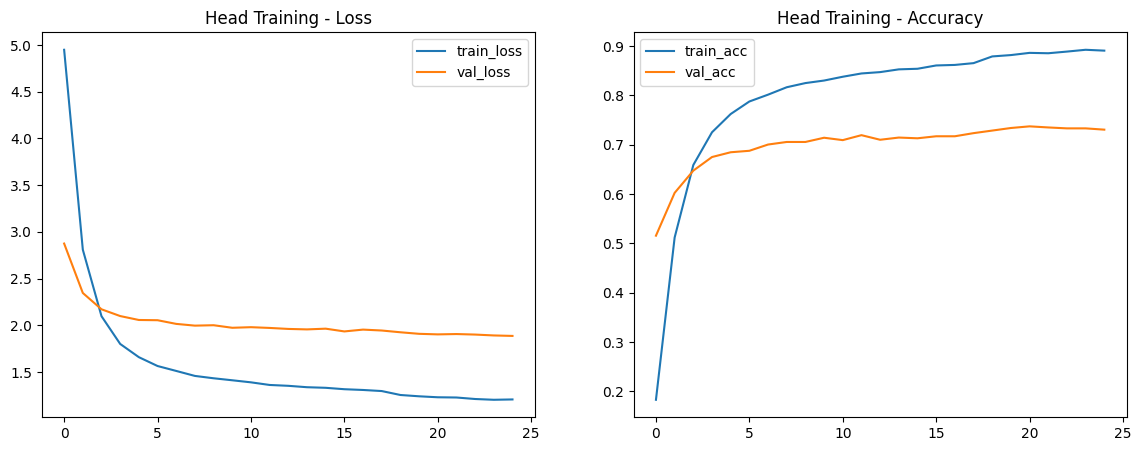

In [23]:
plot_history(history_head, title="Head Training")

In [25]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [26]:
print(y_true[:10])
print(y_pred[:10])

[614 400 400 400 400 682 381 381 381 381]
[674  61 400 681 400 682 381 705 381 378]


In [27]:
print("Head Test Accuracy:", accuracy_score(y_true, y_pred))
print("Head Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Head Macro F1:", f1_score(y_true, y_pred, average="macro"))

Head Test Accuracy: 0.7335398915569326
Head Balanced Accuracy: 0.46093516024333336
Head Macro F1: 0.4161999079877769


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [28]:
top3 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3.update_state(y_true, y_probs)
top5.update_state(y_true, y_probs)

print("Top-3 Head Test Accuracy:", top3.result().numpy())
print("Top-5 Head Test Accuracy:", top5.result().numpy())

Top-3 Head Test Accuracy: 0.8481797
Top-5 Head Test Accuracy: 0.8764524


### Fine-tuning

In [29]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.90)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Total base layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total base layers: 190
Fine-tuning from layer: 171
Trainable layers: 19


In [30]:
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_FINE_1,weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3"),
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top5")
    ]
)

In [31]:
callbacks_fine_1 = [
    keras.callbacks.ModelCheckpoint(
        "best_finetuned_stage1.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        mode="min",
        verbose=1
    )
]

In [32]:
history_fine_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_1,
    callbacks=callbacks_fine_1
)

Epoch 1/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8308 - loss: 1.4108 - top3: 0.9439 - top5: 0.9666
Epoch 1: val_loss improved from inf to 1.92537, saving model to best_finetuned_stage1.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 176s 117ms/step - accuracy: 0.8308 - loss: 1.4108 - top3: 0.9439 - top5: 0.9666 - val_accuracy: 0.7144 - val_loss: 1.9254 - val_top3: 0.8433 - val_top5: 0.8820
Epoch 2/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8426 - loss: 1.3626 - top3: 0.9470 - top5: 0.9677
Epoch 2: val_loss improved from 1.92537 to 1.90701, saving model to best_finetuned_stage1.keras
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 165s 116ms/step - accuracy: 0.8426 - loss: 1.3626 - top3: 0.9470 - top5: 0.9677 - val_accuracy: 0.7200 - val_loss: 1.9070 - val_top3: 0.8474 - val_top5: 0.8838
Epoch 3/10
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8528 - loss: 1.3241 - top3: 0.9543 - top5: 0.9733
Epoch 3: val_loss improved from 1.90701 to 1.89707, saving model to be

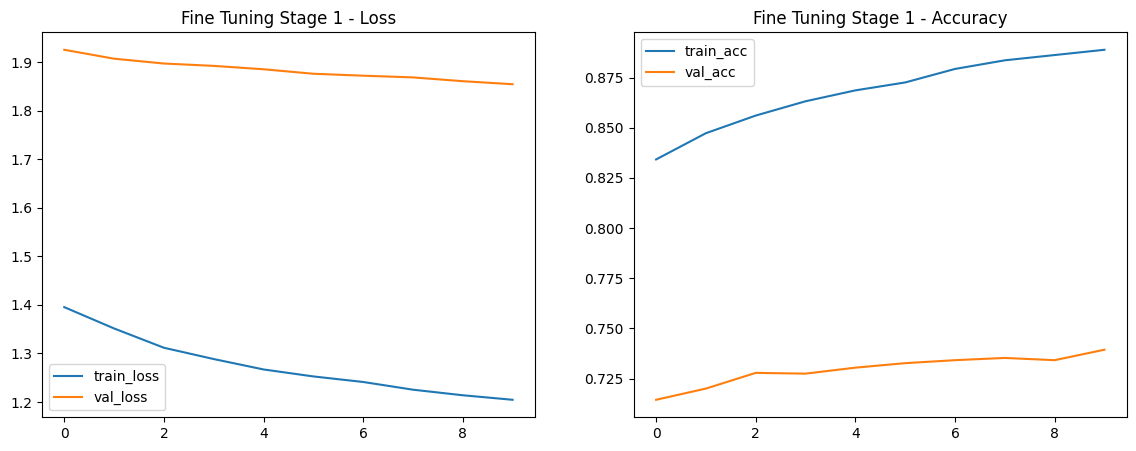

In [33]:
plot_history(history_fine_1, title="Fine Tuning Stage 1")

In [34]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [35]:
print("Fine_Stage1 Test Accuracy:", accuracy_score(y_true, y_pred))
print("Fine_Stage1 Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Fine_Stage1 Macro F1:", f1_score(y_true, y_pred, average="macro"))

Fine_Stage1 Test Accuracy: 0.7482571649883811
Fine_Stage1 Balanced Accuracy: 0.4758968936226898
Fine_Stage1 Macro F1: 0.43042907772872196


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [36]:
top3_2 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_2 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_2.update_state(y_true, y_probs)
top5_2.update_state(y_true, y_probs)

print("Top-3 Fine_Stage1 Test Accuracy:", top3_2.result().numpy())
print("Top-5 Fine_Stage1 Test Accuracy:", top5_2.result().numpy())

Top-3 Fine_Stage1 Test Accuracy: 0.85631293
Top-5 Fine_Stage1 Test Accuracy: 0.8892332


### Testing

In [46]:
model = keras.models.load_model("best_finetuned_stage1.keras")

In [47]:
y_true = []
y_pred = []
y_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

In [48]:
print("Final Test Accuracy:", accuracy_score(y_true, y_pred))
print("Final Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Final Macro F1:", f1_score(y_true, y_pred, average="macro"))

Final Test Accuracy: 0.7482571649883811
Final Balanced Accuracy: 0.4758968936226898
Final Macro F1: 0.43042907772872196


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [49]:
top3_final = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
top5_final = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)

top3_final.update_state(y_true, y_probs)
top5_final.update_state(y_true, y_probs)

print("Final Top-3 Accuracy:", top3_final.result().numpy())
print("Final Top-5 Accuracy:", top5_final.result().numpy())

Final Top-3 Accuracy: 0.85631293
Final Top-5 Accuracy: 0.8892332


In [50]:
test_present_classes = np.unique(y_true)

mask = np.isin(y_true, test_present_classes)

print("Classes in train:", NUM_CLASSES)
print("Classes in test:", len(test_present_classes))

print("Test-present Accuracy:", accuracy_score(y_true[mask], y_pred[mask]))
print("Test-present Balanced Accuracy:", balanced_accuracy_score(y_true[mask], y_pred[mask]))
print("Test-present Macro F1:", f1_score(y_true[mask], y_pred[mask], average="macro"))

Classes in train: 718
Classes in test: 562
Test-present Accuracy: 0.7482571649883811
Test-present Balanced Accuracy: 0.4758968936226898
Test-present Macro F1: 0.43042907772872196


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [51]:
report = classification_report(
    y_true,
    y_pred,
    labels=np.unique(y_true),
    target_names=[class_names[i] for i in np.unique(y_true)],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
class_report_df = report_df.iloc[:-3].copy()

display(class_report_df.sort_values("f1-score").head(30))

,precision,recall,f1-score,support
N12,0.0,0.0,0.0,2.0
Q5,0.0,0.0,0.0,1.0
R2,0.0,0.0,0.0,1.0
T24,0.0,0.0,0.0,1.0
S13,0.0,0.0,0.0,1.0
S11,0.0,0.0,0.0,1.0
S1,0.0,0.0,0.0,1.0
S2,0.0,0.0,0.0,1.0
N13,0.0,0.0,0.0,1.0
R1,0.0,0.0,0.0,1.0


In [52]:
model.save("hieroglyph_resnet150v2_final.keras")

label_map = pd.DataFrame({
    "class_index": list(range(len(class_names))),
    "gardiner_code": class_names
})

label_map.to_csv("label_map.csv", index=False)

print("Saved model and label map.")

Saved model and label map.


In [53]:
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

pd.DataFrame({
    "gardiner_code": list(class_to_idx.keys()),
    "class_index": list(class_to_idx.values())
}).to_csv("class_to_idx.csv", index=False)